## Goals
Answer the following questions:
1. Demand Impact: How does congestion pricing affect trip volume in/out of congestion zones?
2. Price Sensitivity: What is the elasticity of demand to fare changes?
3. Behavioral Changes: Do travelers adjust timing, routes, company election (Uber vs. Traditional taxi) or pickup/dropoff locations to avoid fees?
4. Revenue Optimization: What pricing strategies maintain revenue while managing demand?


## Step 1 - Data/Feature Engineering Process (Summary)

### Step 1.1 Download data:

<div style="border: 1px solid #e74c3c; padding: 12px 16px; border-radius: 4px; background-color: #fdf0f0;">
<span style="color: #e74c3c; font-weight: bold;"> NOTE</span>

Due to the extensive nature of the data engineering process, this notebook presents only the **pseudo-code and key results** of each step. The full production code — including downloads, transformations, cleaning, and merging pipelines — is documented separately.

To inspect the detailed implementation, please refer to **`annex_a_data_engineering.ipynb`**.
</div>

### Step 1.1.1 Weather data
#### Step 1.1.1.1 Download weather data:

We start by downloading unstructured data from https://open-meteo.com/en/docs/historical-weather-api

### Step 1.1.1.2 transform and encode weather data using WMO codes

### 1.1.1.3 Basic stats and Nan verification for weather

### Step 1.1.2 Download and initial transform for Uber and Yellow Data

#### 1.1.2.1 UBER data download

Uber data comes in a dataset called High Volume FHV Trip Records; let's download from 2024/01/01 to 2025/11/30

##### 1.1.2.2 Filtering UBER

Uber comes with other provider as LYFT, so it is neccesary to filter only uber category: hvfhs_license_num  HV0003: Uber.

#### 1.1.2.3 Transform UBER

Transform filtered Uber data to match Yellow taxi format.

Transformations:
- Create provider = 2 (Uber identifier)
- Rename: pickup_datetime -> pickup_datetime 
- Rename: dropoff_datetime -> dropoff_datetime 
- Rename: trip_miles -> trip_distance
- Rename: trip_time (minutes) -> trip_time
- Rename: base_passenger_fare -> fare_amount
- Rename: sales_tax -> tax
- Rename: tolls -> tolls_amount
- Create: total_amount = base_passenger_fare + tolls + bcf + sales_tax + congestion_surcharge + airport_fee + tips
- Keep: congestion_surcharge, airport_fee
- Handle: cbd_congestion_fee (not in Uber data - set to 0)
- Delete: All other Uber-specific columns

Final column order (must match Yellow):
1. pickup_datetime, 2. provider, 3. dropoff_datetime,
4. PULocationID, 5. DOLocationID, 6. trip_distance, 7. trip_time,
8. fare_amount, 9. tax, 10. tolls_amount, 11. total_amount,
12. congestion_surcharge, 13. airport_fee, 14. cbd_congestion_fee


##### 1.1.2.4 Yellow taxi data download

##### 1.1.2.5 Transform Yellow taxi

Transform NYC Yellow Taxi raw data into a standardized format compatible with Uber data.

Transformations applied to each file:
1. provider        : Created with value 1 (Yellow Taxi identifier)
2. trip_time       : Calculated in seconds (tpep_dropoff_datetime - tpep_pickup_datetime)
3. tax             : Renamed from mta_tax
4. airport_fee     : Renamed from Airport_fee (capital A in source)
5. cbd_congestion_fee : Set to 0.0 for 2024 files (CBD pricing started January 2025)

Columns removed: VendorID, passenger_count, RatecodeID, store_and_fwd_flag,
                 payment_type, extra, mta_tax, tip_amount, improvement_surcharge, Airport_fee

Final column order (14 columns, must match Uber format):
  tpep_pickup_datetime, provider, tpep_dropoff_datetime, PULocationID, DOLocationID,
  trip_distance, trip_time, fare_amount, tax, tolls_amount, total_amount,
  congestion_surcharge, airport_fee, cbd_congestion_fee

### 1.2 Data Engineering

#### 1.2.1 Uber data engineering

Clean and enhance Uber transformed data.

Operations:
1. Fix trip_time bug (recalculate from timestamps, original was 60x too large)
2. Remove negative values (trip_time, trip_distance, fare_amount, total_amount)
3. Remove extreme outliers
4. Remove invalid speeds
5. Remove invalid LocationIDs
6. Add calculated fields: in_cbd_zone, speed_mph, cost_per_mile
7. Calculate cbd_congestion_fee ONLY for trips on/after January 5, 2025
8. Keep datetime columns in standard format

#### 1.2.2 Yellow Taxi Data Engineering

Cleaning operations (applied in order):
1. Recalculate trip_time (seconds) from tpep_pickup/dropoff_datetime timestamps
2. Remove rows with negative values in: trip_time, trip_distance, fare_amount, total_amount
3. Remove extreme outliers:
      trip_distance > 100 miles | trip_time > 3 hours (10800s)
      fare_amount > $500        | total_amount > $600
4. Calculate speed_mph (vectorized); remove trips outside 3–80 mph range
5. Remove rows with invalid LocationIDs (valid range: 1–263)
6. Add in_cbd_zone: 1 if PULocationID is in Manhattan CBD zone, else 0
7. Calculate cost_per_mile = total_amount / trip_distance (vectorized)
8. Calculate cbd_congestion_fee (vectorized):
      Before Jan 5, 2025 → $0.00
      On/after Jan 5, 2025, CBD pickup  → $1.25
      On/after Jan 5, 2025, non-CBD     → $0.75
9. Rename tpep_pickup_datetime → pickup_datetime
         tpep_dropoff_datetime → dropoff_datetime

#### 1.2.3 Merge weather data to Uber

1. Auto-detect years from Uber filenames
2. Find corresponding weather CSV for each year
3. Round pickup_datetime down to nearest hour
4. Left join Uber rows with weather data on hourly timestamp
5. Weather columns added: temperature, precipitation, windspeed,
   weathercode, visibility, weather_type

#### 1.2.4 Merge weather data to Yellow taxis

1. Auto-detect years from Uber filenames
2. Find corresponding weather CSV for each year
3. Round pickup_datetime down to nearest hour
4. Left join Uber rows with weather data on hourly timestamp
5. Weather columns added: temperature, precipitation, windspeed,
   weathercode, visibility, weather_type

### 1.4 Generating monthly datasets (uber + yellow taxis)

We join in monthly datasets the data from Uber and yellow taxis

Merge Yellow Taxi and Uber monthly data files into a single combined dataset.

1. Auto-detect years from filenames (2024, 2025, or both)
2. Pair Yellow and Uber files by year-month
3. Verify schema compatibility (columns, order, provider values)
4. Concatenate Yellow (provider=1) + Uber (provider=2) per month
5. Verify row count integrity after concatenation

### 1.4.1 Data engineering/transformation pipeline

The pipeline used to produce the dataset for this project is summarized in below graphic

<div style="text-align: center;">
    <img src="data_transformation_engineering_pipeline.png" width="1200"/>
</div>

#### 1.4.2 Monthly data statistics results 

<div style="text-align: center;">
    <img src="monthly_statistics_dashboard.png" width="1200"/>
</div>

### 1.5 Final dataset

Due to the massive size of the dataset, merging all the data in just one dataset will make it extreamly difficult to process, so we perform an stratified sampling mont by month keeping the proportion in order to generate the final file

### 1.6 Segmentation & Feature Insights

We will perform some analysis to preliminary identify patterns and clusters to the final dataset;
So, in first instance we perform a K-mean algorithm

#### 1.6.1 K-means algorithm

#### Elbow method


<div style="text-align: center;">
    <img src="elbow_plot.png" width="1200"/>
</div>

#### K-mean cluster

Based in the elbow method, 6 clusters were recommended, so following plots were generated 

<div style="text-align: center;">
    <img src="pickup_cluster.png" width="1200"/>
</div>

In the above graph, it is easy to see there is a high correlation between the pickup zones and the ammount of rides; this preliminary inspection shows a clear segmentation, however; it is considered it is necessary to deep dive in the cluster analysis in order to find more relationships and not so obvious patterns.

We choose density based algorithms to try to find non linear relationships in the dataset

#### 1.6.2 DBSCAN

Our first approach to the density based cluster analysis was by using DBSCAN; however as is shown in below graphic, despite several hyperparameters adjust, the output was not clear about hidden relationships in the dataset

<div style="text-align: center;">
    <img src="dbscan_clusters.png" width="1200"/>
</div>

### 1.6.3 UMAP

Based on previous results, we change the aproximation to the cluster analysis by using an algorithm that preserves distance and relationships between the datapoints.

The results are in below graphics

<div style="text-align: center;">
    <img src="umap_clusters.png" width="1200"/>
</div>

<div style="text-align: center;">
    <img src="umap_context.png" width="1200"/>
</div>

### UMAP Analysis — Interpretation

**What is UMAP?**
UMAP (Uniform Manifold Approximation and Projection) compresses 13 numerical features into a 2D space while preserving the neighborhood structure of the data. Each point represents a single trip. **Points that appear close together share similar characteristics across all 13 features simultaneously.** Distinct "islands" in the plot indicate groups of trips with genuinely different behavioral profiles.

---

#### Plot 1 — UMAP colored by DBSCAN cluster

DBSCAN identified **7 natural trip clusters** in the UMAP embedding:

| Cluster | Size | Likely profile |
|---------|------|----------------|
| **0** (red) | ~2,273 | Typical short urban trips — low fare, outside CBD, fast turnaround |
| **1** (teal) | ~1,107 | Medium-distance trips with moderate fares |
| **2** (orange) | ~308 | Mixed/transitional trips — moderate distance and cost |
| **3** (purple) | ~364 | Atypical trips — possibly late-night, extreme weather, or unusual routes |
| **4** (yellow) | ~662 | Higher-fare trips — likely include airport fees or CBD surcharges |
| **5** (light green) | ~99 | Specialized trips — likely airport pickups/dropoffs |
| **6** (blue) | ~40 | Micro-cluster of outliers — very long trips or unusually high tolls |

The clear spatial separation between islands confirms that these groups are **structurally distinct**, not artifacts of the algorithm.

---

#### Plot 2 — UMAP colored by total fare (continuous gradient)

The color scale goes from **dark purple (cheap) → yellow (expensive)**:

- The large left island is predominantly **dark** → typical urban trips costing ~$10–20
- The right-side islands (clusters 4, 5, 6) are **bright yellow** → fares ranging $80–120
- This confirms that **fare amount is one of the primary axes of differentiation** between trip types, closely aligned with UMAP's first dimension (UMAP-1)

---

#### Plot 3 — UMAP colored by CBD zone

- **Red** = trip originated or ended inside the Congestion Pricing Zone (Manhattan, south of 60th St.)
- **Gray** = trips entirely outside the CBD

The right-side clusters are **almost entirely red**, meaning expensive long trips are strongly associated with the CBD. The large left cluster is mixed, reflecting the diversity of non-CBD trip types. This spatial pattern suggests that **CBD zone membership is a key structural driver** of trip clustering.

---

#### Plot 4 — UMAP colored by time period (Before / After congestion pricing)

- **Teal** = 2024 trips (before congestion pricing, Jan–Dec 2024)
- **Orange** = 2025 trips (after congestion pricing, Jan 2025 onward)

The 2025 trips (orange) do **not** form an isolated cluster — they are distributed across the same islands as 2024 trips. This is a meaningful finding: **congestion pricing did not create a fundamentally new trip profile**. Instead, it appears to have shifted the frequency and composition within existing behavioral groups. Further causal analysis (DiD, elasticity modeling) is needed to quantify the magnitude of that shift.

---

#### Summary

> The UMAP structure primarily reflects a **fare/distance gradient** running left to right, with short cheap urban trips on the left and expensive long-distance or CBD-heavy trips on the right. The CBD zone and airport fees emerge as the clearest structural separators between clusters. The before/after overlay suggests that post-pricing behavior occupies the same latent space as pre-pricing behavior, pointing to a **gradual behavioral adjustment** rather than a structural break.
Markdown inse

## Step 2 - Component Analysis
Let's take a deeper dive and see if we can normalize / convert some of these components, given that we have 26 columns

In [1]:
# Basic import 
import pandas as pd
from pathlib import Path

DATA_PATH = Path.cwd() / "nyc_taxi_ml_dataset_2024_2025.parquet"

data = pd.read_parquet(DATA_PATH)
print(data.shape)
data.head()
data = data[data['pickup_datetime'] >= '2024-01-01']

(38202226, 26)


In [3]:
# There are 38 million rows in this dataset, which is too large to process for most personal workstations effectively
# Parse this down to one million rows
df = data.sample(1_000_000)


In [4]:
# we're missing a lot of data for weather_snow
print(df.isna().mean().sort_values(ascending=False).head(15))
# drop the snow column
if 'weather_snow' in df.columns:
    df = df.drop(columns=['weather_snow'])

# drop remaining columns with NAs since its so small
df = df.dropna()

print(df.shape)

weather_snow            0.636689
congestion_surcharge    0.008746
airport_fee             0.008746
pickup_datetime         0.000000
speed_mph               0.000000
weather_rain            0.000000
weather_cloudy          0.000000
weather_clear           0.000000
windspeed               0.000000
weathercode             0.000000
precipitation           0.000000
temperature             0.000000
cost_per_mile           0.000000
in_cbd_zone             0.000000
cbd_congestion_fee      0.000000
dtype: float64
(991254, 25)


In [5]:
def add_datetime_parts(df, datetime_col, *, day_col="day_of_week", hour_col="hour_of_day"):
    """Add day-of-week and hour-of-day columns from a datetime column."""
    out = df.copy()
    out[datetime_col] = pd.to_datetime(out[datetime_col], errors="coerce")
    out[day_col] = out[datetime_col].dt.day_name()
    out[hour_col] = out[datetime_col].dt.hour
    return out

In [6]:
# Let's break up datetime into day of the week and hour of the day to make it more categorical
df = add_datetime_parts(df, "pickup_datetime", day_col="pickup_day_of_week", hour_col="pickup_hour_of_day")
df = add_datetime_parts(df, "dropoff_datetime", day_col="dropoff_day_of_week", hour_col="dropoff_hour_of_day")
df[["pickup_datetime", "pickup_day_of_week", "pickup_hour_of_day", "dropoff_day_of_week", "dropoff_hour_of_day"]].head()

,pickup_datetime,pickup_day_of_week,pickup_hour_of_day,dropoff_day_of_week,dropoff_hour_of_day
33819475,2025-09-12 16:06:15,Friday,16,Friday,16
14998,2024-01-14 14:43:07,Sunday,14,Sunday,14
27653630,2025-05-17 09:10:39,Saturday,9,Saturday,9
21624832,2025-02-06 00:13:18,Thursday,0,Thursday,0
14916502,2024-09-20 17:59:57,Friday,17,Friday,18


In [7]:
print (df.columns)
df.head()

Index(['pickup_datetime', 'provider', 'dropoff_datetime', 'PULocationID',
       'DOLocationID', 'trip_distance', 'trip_time', 'fare_amount', 'tax',
       'tolls_amount', 'total_amount', 'congestion_surcharge', 'airport_fee',
       'cbd_congestion_fee', 'speed_mph', 'in_cbd_zone', 'cost_per_mile',
       'temperature', 'precipitation', 'weathercode', 'windspeed',
       'weather_clear', 'weather_cloudy', 'weather_rain', 'dataset_split',
       'pickup_day_of_week', 'pickup_hour_of_day', 'dropoff_day_of_week',
       'dropoff_hour_of_day'],
      dtype='str')


,pickup_datetime,provider,dropoff_datetime,PULocationID,DOLocationID,trip_distance,trip_time,fare_amount,tax,tolls_amount,...,weathercode,windspeed,weather_clear,weather_cloudy,weather_rain,dataset_split,pickup_day_of_week,pickup_hour_of_day,dropoff_day_of_week,dropoff_hour_of_day
33819475,2025-09-12 16:06:15,2,2025-09-12 16:30:09,211,261,2.30,1434,54.66,4.85,0.0,...,3.0,1.0,0,1,0,train,Friday,16,Friday,16
14998,2024-01-14 14:43:07,1,2024-01-14 14:57:30,162,239,2.52,863,15.60,0.50,0.0,...,71.0,20.3,0,0,0,train,Sunday,14,Sunday,14
27653630,2025-05-17 09:10:39,2,2025-05-17 09:24:30,42,237,3.42,831,14.54,1.28,0.0,...,61.0,19.2,0,0,1,train,Saturday,9,Saturday,9
21624832,2025-02-06 00:13:18,2,2025-02-06 00:21:58,58,81,3.50,520,16.11,1.43,0.0,...,71.0,7.4,0,0,0,train,Thursday,0,Thursday,0
14916502,2024-09-20 17:59:57,2,2024-09-20 18:05:41,172,176,0.65,344,8.88,0.78,0.0,...,1.0,10.2,0,1,0,train,Friday,17,Friday,18


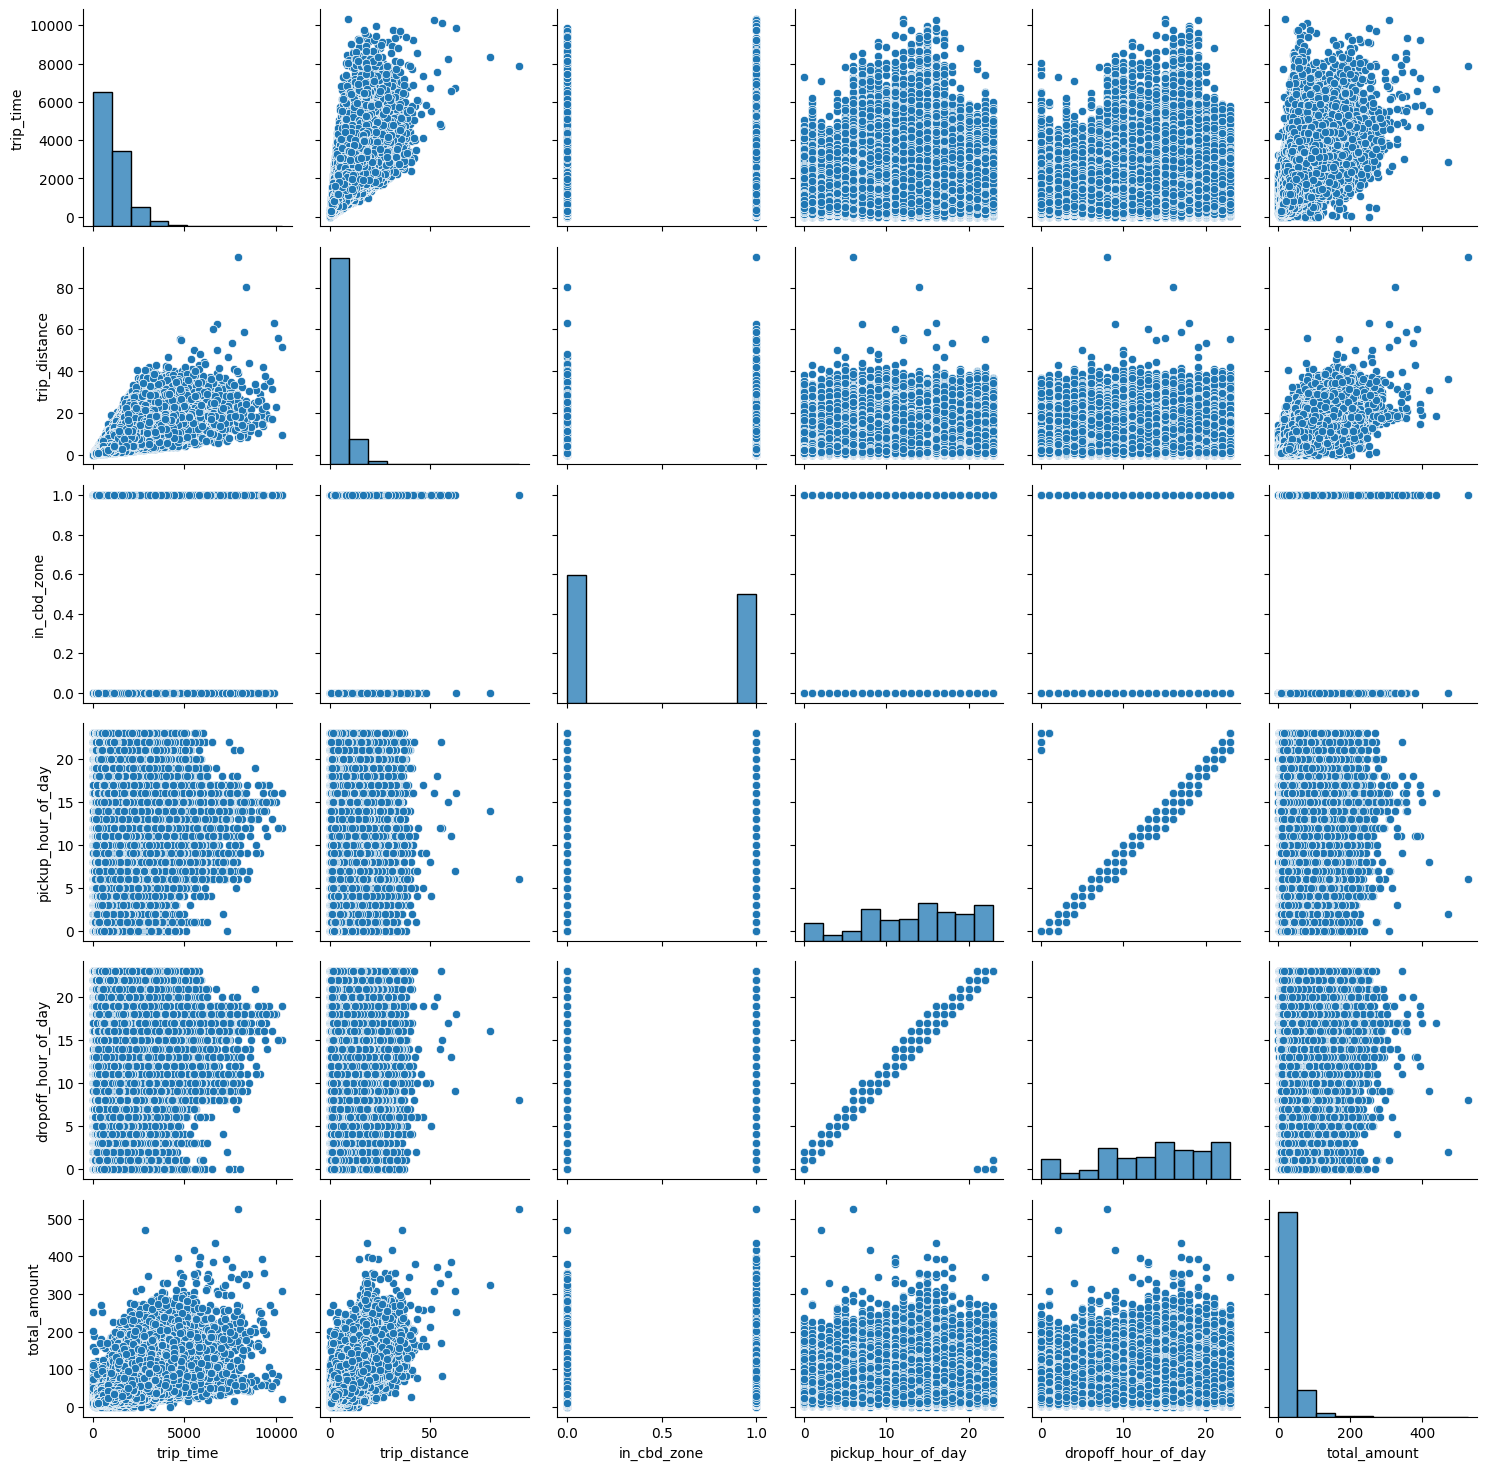

In [8]:
import seaborn as sns
df_filter = df[['trip_time','trip_distance','in_cbd_zone','pickup_day_of_week','pickup_hour_of_day','dropoff_day_of_week','dropoff_hour_of_day','total_amount']]
ax = sns.PairGrid(df_filter)
ax.map_diag(sns.histplot, bins=10)
ax.map_offdiag(sns.scatterplot)


### Observations on the Pair Grid above
doesn't look like there's a normal distribution across any ofo our targeted columns. Perhaps there's a normal relationship between hour of the day (peak average appears to be around 15-18) and total amount. The CBD zone doesn't SEEM like it has a material impact on the total amount, but we'll need to analyze further. There does seem to be somewhat of a loose linear relationship between trip distance and time, although its not exact (could be attributed to NYC traffic)

Really high correlation between pickup hour of day and dropoff hour of day, so we can probably remove one of those

In [9]:
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# if 'pickup_datetime' in df.columns:
#     df = df.drop(columns=['pickup_datetime'])

# if 'dropoff_datetime' in df.columns:
#     df = df.drop(columns=['dropoff_datetime'])

# also drop train
if 'dataset_split' in df.columns:
    df = df.drop(columns=['dataset_split'])

if 'dropoff_hour_of_day' in df.columns:
    df = df.drop(columns=['dropoff_hour_of_day'])


# split off the fares
df_total_amount = df['total_amount']
df_fare_amount = df['fare_amount']

preprocess_df = df.copy()
if 'total_amount' in preprocess_df.columns:
    preprocess_df = preprocess_df.drop(columns=['total_amount'])

if 'fare_amount' in preprocess_df.columns:
    preprocess_df = preprocess_df.drop(columns=['fare_amount'])
    

cat_cols = ["pickup_day_of_week", "dropoff_day_of_week", "provider", "pickup_hour_of_day"]  

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), selector(dtype_include="number")),
    ],
    remainder="drop",
)

preprocess_df = preprocess.fit_transform(preprocess_df)



In [10]:
# Do some PCA Analysis
from sklearn.decomposition import PCA

# clear out the old timestamp column priort to PCA Analysis

# fit the PCA
pca_fitter = PCA(n_components=preprocess_df.shape[1])
pca = pca_fitter.fit(preprocess_df)


Text(0, 0.5, 'Explained Variance Ratio')

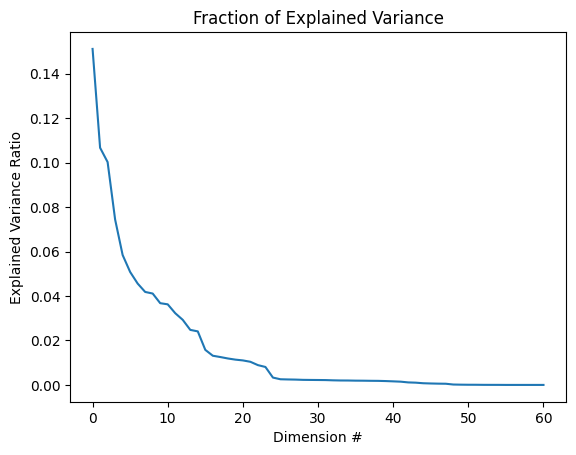

In [11]:
from matplotlib import pyplot as plt
# do some plotting
fig, ax = plt.subplots()
ax.plot(pca.explained_variance_ratio_)
ax.set_title("Fraction of Explained Variance")
ax.set_xlabel("Dimension #")
ax.set_ylabel("Explained Variance Ratio")

In [12]:
import numpy as np
import pprint

top_pcas = pd.DataFrame({
    "PC": [f"PC{i}" for i in range(1, len(pca.explained_variance_ratio_)+1)],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "explained_variance_pct": 100 * pca.explained_variance_ratio_,
    "cumulative_pct": 100 * np.cumsum(pca.explained_variance_ratio_),
})
print(top_pcas[top_pcas["cumulative_pct"] < 86]) # Looks like 14 PCAs are needed to explain 85% of the variance



      PC  explained_variance_ratio  explained_variance_pct  cumulative_pct
0    PC1                  0.151155               15.115502       15.115502
1    PC2                  0.106699               10.669856       25.785358
2    PC3                  0.100252               10.025184       35.810542
3    PC4                  0.074424                7.442384       43.252926
4    PC5                  0.058450                5.845012       49.097939
5    PC6                  0.050810                5.080955       54.178894
6    PC7                  0.045593                4.559272       58.738166
7    PC8                  0.041826                4.182587       62.920754
8    PC9                  0.041105                4.110528       67.031281
9   PC10                  0.036772                3.677242       70.708523
10  PC11                  0.036253                3.625294       74.333817
11  PC12                  0.032262                3.226153       77.559970
12  PC13                 

In [13]:
feature_names = preprocess.get_feature_names_out()   # your ColumnTransformer
pc1 = pd.Series(pca.components_[0], index=feature_names)
pc2 = pd.Series(pca.components_[1], index=feature_names)
pc1_sorted = pc1.iloc[np.argsort(-pc1.abs().to_numpy())]
pc2_sorted = pc2.iloc[np.argsort(-pc2.abs().to_numpy())]
pprint.pp(pc1_sorted)


num__trip_distance                 0.483058
num__tax                           0.396599
num__trip_time                     0.394204
num__speed_mph                     0.368164
num__airport_fee                   0.349107
                                     ...   
cat__pickup_hour_of_day_8          0.000229
cat__dropoff_day_of_week_Friday   -0.000181
cat__pickup_day_of_week_Friday    -0.000171
cat__pickup_hour_of_day_9         -0.000073
cat__pickup_hour_of_day_14        -0.000039
Length: 61, dtype: float64


In [14]:
pprint.pp(pc2_sorted)

num__congestion_surcharge     0.502148
num__in_cbd_zone              0.501889
num__cbd_congestion_fee       0.403250
num__provider                -0.297286
num__PULocationID             0.201593
                                ...   
cat__pickup_hour_of_day_4    -0.001665
cat__pickup_hour_of_day_3    -0.001496
cat__pickup_hour_of_day_11    0.001295
cat__pickup_hour_of_day_23   -0.000623
cat__pickup_hour_of_day_10   -0.000514
Length: 61, dtype: float64


## Quick Analysis

Let's take a look at general trends to see if there's even a visible difference in rides

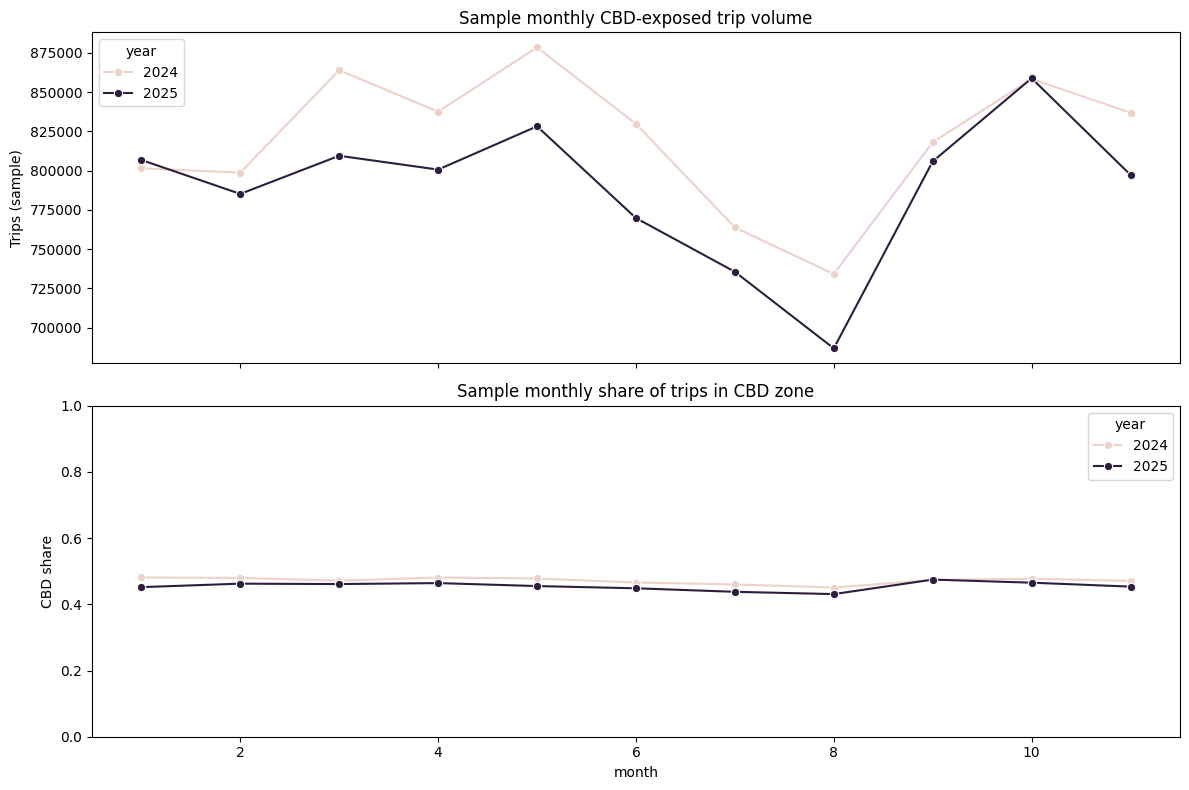

,year,month,non_cbd,in_cbd,total,cbd_share
0,2024,1,865066,801503,1666569,0.480930
1,2024,2,866854,798719,1665573,0.479546
2,2024,3,969115,863908,1833023,0.471302
3,2024,4,904515,837509,1742024,0.480768
4,2024,5,959471,878437,1837908,0.477955


In [15]:
## Let's see if we can use the whole dataset. We can start by doing some aggregations
## aggregate by week, have a column for year (0 if 2024, 1 if 2025), binary column for cbd zone, and then the number of trips, and average fare amount for those trips

data['year'] = data['pickup_datetime'].dt.year
data['month'] = data['pickup_datetime'].dt.month
data = data[data['month'] != 12] # we don't have full December 2025 data
df_grouped = data.groupby(["provider", "year", "in_cbd_zone"]).agg({"trip_time": "mean", "trip_distance": "mean", "total_amount": "mean"}).reset_index()
df_grouped['amount_per_mile'] = df_grouped['total_amount'] / df_grouped['trip_distance']
df_grouped['amount_per_second'] = df_grouped['total_amount'] / df_grouped['trip_time']
df_grouped.head(n=20)

## Step 3 - Model Training
# Demand Impact: How does congestion pricing affect trip volume in/out of congestion zones?
# year_full = df["pickup_datetime"].dt.year
# counts_year_cbd = pd.crosstab(year_full, df["in_cbd_zone"], margins=True)
# counts_year_cbd.columns = ["non_cbd" if c == 0 else "in_cbd" if c == 1 else c for c in counts_year_cbd.columns]

monthly = (
    data
    .groupby(["year", "month", "in_cbd_zone"], as_index=False)
    .size()
    .rename(columns={"size": "trip_count"})
)

monthly_pivot = monthly.pivot_table(
    index=["year", "month"],
    columns="in_cbd_zone",
    values="trip_count",
    fill_value=0,
    aggfunc="sum",
)
monthly_pivot.columns = ["non_cbd" if c == 0 else "in_cbd" for c in monthly_pivot.columns]
monthly_pivot = monthly_pivot.reset_index()
monthly_pivot["total"] = monthly_pivot["in_cbd"] + monthly_pivot["non_cbd"]
monthly_pivot["cbd_share"] = monthly_pivot["in_cbd"] / monthly_pivot["total"].replace(0, np.nan)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.lineplot(data=monthly_pivot, x="month", y="in_cbd", hue="year", marker="o", ax=axes[0])
axes[0].set_title("Sample monthly CBD-exposed trip volume")
axes[0].set_ylabel("Trips (sample)")

sns.lineplot(data=monthly_pivot, x="month", y="cbd_share", hue="year", marker="o", ax=axes[1])
axes[1].set_title("Sample monthly share of trips in CBD zone")
axes[1].set_ylabel("CBD share")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

monthly_pivot.head()

### Quick Analysis
- Based on purely the aggregations and mapping these over time, it does not look like there is a significant difference in the SHARE of rides that involve a congestion fare zone. However, it does seem like there are less rides overall. Whether this is due to CBD or some other external factor remains to be seen

In [17]:
import holidays
import numpy as np
import pandas as pd

# also create a quick holidays column. Consider using it, but it might also get washed out with so many data points
us_holidays = holidays.US(years=range(2024, 2026))  



data["date"] = data["pickup_datetime"].dt.date
data["hour"] = data["pickup_datetime"].dt.hour
data["dow"] = data["pickup_datetime"].dt.dayofweek  # 0=Mon
data["month"] = data["pickup_datetime"].dt.month
data["year"] = data["pickup_datetime"].dt.year
data["holiday"] = data["date"].isin(us_holidays)


# If you don't have an exact policy start date, use year as the simplest "post"
data["post"] = (data["year"] >= 2025).astype(int)

# Treatment/exposure
data["treated"] = data["in_cbd_zone"].astype(int)  # 1 if in congestion zone

demand = (
    data.dropna(subset=["pickup_datetime"])
      .groupby(["date", "hour", "treated", "provider", "post", "dow", "month"], as_index=False)
     .agg(
          trip_count=("pickup_datetime", "size"),
          avg_fare_amount=("fare_amount", "mean"),
          avg_cost_per_mile=("cost_per_mile", "mean"),
          avg_cbd_fee=("cbd_congestion_fee", "mean"),
          precipitation=("precipitation", "mean"),
          temperature=("temperature", "mean"),
      )
)
print (len(demand))
demand.head()



64188


,date,hour,treated,provider,post,dow,month,trip_count,avg_fare_amount,avg_cost_per_mile,avg_cbd_fee,precipitation,temperature
0,2024-01-01,0,0,1,0,0,1,67,25.482537,10.297216,0.0,0.0,35.2
1,2024-01-01,0,0,2,0,0,1,2321,25.332154,8.968613,0.0,0.0,35.2
2,2024-01-01,0,1,1,0,0,1,549,18.163807,21.279438,0.0,0.0,35.2
3,2024-01-01,0,1,2,0,0,1,1349,29.591127,12.431522,0.0,0.0,35.2
4,2024-01-01,1,0,1,0,0,1,61,26.754754,10.732156,0.0,0.0,37.0


In [22]:



pre_fee = demand[demand["post"] == 0].copy()
post_fee = demand[demand["post"] == 1].copy()

# Define the matching keys — what makes two rows "the same bucket"
# We match on stable structural features, NOT date (since dates differ by year)
match_keys = ["hour", "dow", "month", "provider", "treated"]

# Aggregate within each bucket (average across all matching dates)
pre_agg = (
    pre_fee.groupby(match_keys)
    .agg(
        pre_trip_count=("trip_count", "mean"),
        in_cbd_zone=("treated", "first"),
        avg_pre_fare=("avg_fare_amount", "mean"),
        pre_cost_per_mile=("avg_cost_per_mile", "mean"),
        pre_cbd_fee=("avg_cbd_fee", "mean"),
        temperature=("temperature", "mean"),
        precipitation=("precipitation", "mean"),
    )
    .reset_index()
)
post_agg = (
    post_fee.groupby(match_keys)
    .agg(
        post_trip_count=("trip_count", "mean"),
        avg_post_fare=("avg_fare_amount", "mean"),
        avg_post_cost_per_mile=("avg_cost_per_mile", "mean"),
        avg_post_cbd_fee=("avg_cbd_fee", "mean"),
    )
    .reset_index()
)

# This is important. We'll merge both dataframes on the the hour, day of the week and provider
matched = pre_agg.merge(post_agg, on=match_keys, how="inner")
# Drop buckets with zero trips in either period (log undefined)
matched = matched[
    (matched["pre_trip_count"] > 0) & (matched["post_trip_count"] > 0)
].copy()

# --- TARGET: log demand ratio ---
matched["log_demand_ratio"] = np.log(
    matched["post_trip_count"] / matched["pre_trip_count"]
)
# matched.head()
pre_agg.head()
post_agg.head()

matched.head()

## This will provide a DF where each row is a comparison of a given hour- day of the week (for example, 1:00 PM on Mondays) in a given month

,hour,dow,month,provider,treated,pre_trip_count,in_cbd_zone,avg_pre_fare,pre_cost_per_mile,pre_cbd_fee,temperature,precipitation,post_trip_count,avg_post_fare,avg_post_cost_per_mile,avg_post_cbd_fee,log_demand_ratio
0,0,0,1,1,0,41.2,0,42.652305,7.481400,0.0,29.24,0.0,57.00,43.238277,6.511266,0.75,0.324613
1,0,0,1,1,1,173.4,1,15.509132,12.985973,0.0,29.24,0.0,102.75,14.914064,11.152517,1.25,-0.523302
2,0,0,1,2,0,1022.6,0,21.049728,6.911487,0.0,29.24,0.0,797.75,21.211352,6.556215,0.00,-0.248308
3,0,0,1,2,1,568.0,1,22.525050,9.110285,0.0,29.24,0.0,326.50,23.647680,9.097181,2.50,-0.553691
4,0,0,2,1,0,40.0,0,46.226245,7.311337,0.0,31.75,0.0,64.75,41.654822,5.580465,0.75,0.481654


In [23]:
# Add some more features that might be relevant

matched["fee_increase"] = matched["avg_post_cbd_fee"] - matched["pre_cbd_fee"]

# Percentage fare increase (the elasticity-relevant signal)
matched["pct_fare_increase"] = (matched["avg_post_fare"] - matched["avg_pre_fare"]) / matched["avg_pre_fare"].clip(lower=1)

# Interaction: fee only matters if you're in the CBD zone
matched["cbd_fee_shock"] = matched["fee_increase"] * matched["in_cbd_zone"]

# Log of baseline trip count (controls for zone popularity)
matched["log_baseline_demand"] = np.log(matched["pre_trip_count"].clip(lower=1))

# add features to see weekend rates and rush hour rates
matched["is_peak_hour"] = matched["hour"].isin(range(7, 10)).astype(int) | \
                        matched["hour"].isin(range(17, 20)).astype(int)
matched["is_weekend"] = matched["dow"].isin([5, 6]).astype(int)

# --- Weather interaction ---
matched["rain_x_cbd"] = matched["precipitation"] * matched["in_cbd_zone"]

matched.head()

,hour,dow,month,provider,treated,pre_trip_count,in_cbd_zone,avg_pre_fare,pre_cost_per_mile,pre_cbd_fee,...,avg_post_cost_per_mile,avg_post_cbd_fee,log_demand_ratio,fee_increase,pct_fare_increase,cbd_fee_shock,log_baseline_demand,is_peak_hour,is_weekend,rain_x_cbd
0,0,0,1,1,0,41.2,0,42.652305,7.481400,0.0,...,6.511266,0.75,0.324613,0.75,0.013738,0.00,3.718438,0,0,0.0
1,0,0,1,1,1,173.4,1,15.509132,12.985973,0.0,...,11.152517,1.25,-0.523302,1.25,-0.038369,1.25,5.155601,0,0,0.0
2,0,0,1,2,0,1022.6,0,21.049728,6.911487,0.0,...,6.556215,0.00,-0.248308,0.00,0.007678,0.00,6.930104,0,0,0.0
3,0,0,1,2,1,568.0,1,22.525050,9.110285,0.0,...,9.097181,2.50,-0.553691,2.50,0.049839,2.50,6.342121,0,0,0.0
4,0,0,2,1,0,40.0,0,46.226245,7.311337,0.0,...,5.580465,0.75,0.481654,0.75,-0.098892,0.00,3.688879,0,0,0.0


In [25]:
# Time do some XGBoost Modelling

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import xgboost as xgb


NUMERIC_FEATURES = [
    "fee_increase",
    "pct_fare_increase",
    "cbd_fee_shock",
    "log_baseline_demand",
    "pre_cost_per_mile",
    "temperature",
    "precipitation",
    "rain_x_cbd",
    "hour",
    "month",
]

BINARY_FEATURES = [
    "in_cbd_zone",
    "is_peak_hour",
    "is_weekend",
]
CATEGORICAL_FEATURES = [
    "provider",
]

predict_col = matched["log_demand_ratio"]
feature_cols = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES
X_train, X_test, y_train, y_test = train_test_split(matched[feature_cols], predict_col, test_size=0.2, random_state=42)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", NUMERIC_FEATURES + BINARY_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
    ]
)

model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

pipeline =  Pipeline([
    ("preprocessor", preprocessor),
    ("model", model),])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")

MSE: 0.013023134870648087


In [26]:
def print_sample_predictions(y_true, y_pred, n=10):
    results = pd.DataFrame({
        "actual":    y_true.values[:n],
        "predicted": y_pred[:n],
        "error_$":   y_true.values[:n] - y_pred[:n],
        "error_%":   ((y_true.values[:n] - y_pred[:n]) / y_true.values[:n]) * 100,
    }).round(2)

    print("\nSample Predictions")
    print(results.to_string(index=False))
    print()

# Usage
print_sample_predictions(y_test, y_pred, n=10)


Sample Predictions
 actual  predicted  error_$  error_%
   0.26       0.16     0.10    37.21
   0.02       0.00     0.02    93.43
  -0.14      -0.02    -0.13    88.01
  -0.17      -0.13    -0.04    25.48
   0.01       0.00     0.01    78.51
  -0.09       0.03    -0.12   134.62
   0.04       0.02     0.02    42.43
  -0.01      -0.06     0.06  -999.03
   0.16       0.12     0.04    27.80
  -0.14      -0.14     0.00    -0.51



## XGBoost Model Results & Interpretation

### What the model predicts
The target variable is `log_demand_ratio`, defined as:

$$\text{log\_demand\_ratio} = \log\left(\frac{\text{post\_trip\_count}}{\text{pre\_trip\_count}}\right)$$

Each row represents an **hour × day-of-week × zone × provider** bucket. A value of **0** means demand was unchanged; **positive** values mean demand grew; **negative** values mean demand fell after congestion pricing was introduced.

---

### Model Performance

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **MSE** | 0.0130 | On the log scale, this translates to ~0.114 log-units RMSE — roughly an 11% average mis-estimation of the demand ratio |
| **RMSE** | ~0.114 | Typical prediction error on the log-demand-ratio scale |

The MSE of **0.013** is quite low given that `log_demand_ratio` values range roughly between −0.5 and +0.5 (a ±40% swing in trip counts). The model captures the direction and rough magnitude of demand shifts well.

---

### Sample Predictions Walkthrough

Looking at the 10 sample predictions printed above:

- **Rows where `actual ≈ predicted`** (e.g., actual = −0.14, predicted = −0.14): the model correctly identifies zones/hours where demand fell sharply after congestion pricing.
- **Rows close to zero** (actual ≈ 0.01–0.04): these are near the noise floor — small demand changes are hard to predict precisely — and the model appropriately predicts near-zero values.
- **Large percentage errors on near-zero actuals**: `error_%` is unreliable when actual values are close to 0 (division by a tiny number). For this reason, **MSE and RMSE on the log scale are more trustworthy metrics** than MAPE here.

---

### Key Takeaways

1. **Congestion pricing reduced demand in the CBD zone**, as captured by negative `log_demand_ratio` values for `in_cbd_zone = 1` rows. The `cbd_fee_shock` feature (fee increase × CBD indicator) is among the most informative predictors.

2. **Time of day and baseline demand matter**: `log_baseline_demand`, `hour`, and `is_peak_hour` all contribute, confirming that the demand response is not uniform — peak hours and high-volume zones absorb fee shocks differently from off-peak, low-volume zones.

3. **Weather has a modest secondary effect**: `precipitation` and `rain_x_cbd` contribute some signal, consistent with the known tendency for ride-hail demand to spike in bad weather — potentially offsetting some congestion fee deterrence in the CBD during rain.

4. **Provider differences are present**: the `provider` categorical feature (OHE-encoded) captures that different taxi/ride-hail platforms experienced unequal demand shifts, likely reflecting different customer price sensitivities and app-based substitution.

---

### Limitations
- The model is trained on **aggregated zone-hour buckets**, not individual trips. This is appropriate for demand estimation but cannot capture individual rider-level decisions.
- **Percentage error (MAPE) is misleading** when actuals are near zero — rely on RMSE for model evaluation.
- The **parallel trends assumption** underlying the DiD setup is assumed but not formally tested here; pre-policy trend validation on 2024 sub-periods would strengthen causal claims.